# Metric Spaces and Basic Topology

## Motivating Example: Completion

### Example 1: Completion of $\mathbb{Q}$
The rational numbers $\mathbb{Q}$ with the usual metric $d(x,y)=|x-y|$ are **not complete**:

- there exist Cauchy sequences in $\mathbb{Q}$ that do not converge in $\mathbb{Q}$, but converge in $\mathbb{R}$.  

For instance, consider the sequence defined recursively by
$$
x_1 = 1, \quad x_{n+1} = \frac{x_n}{2} + \frac{1}{x_n}, \quad n \ge 1,
$$
which approximates $\sqrt{2}$. Each $x_n \in \mathbb{Q}$, but the limit $\sqrt{2}\notin\mathbb{Q}$.

In [ ]:
# Python demo: Cauchy sequence in Q approximating sqrt(2)
x = 1.0  # start with rational approximation
seq = [x]
for _ in range(20):
    x = x/2 + 1/x
    seq.append(x)
print("Last 5 elements:", seq[-5:])


Last 5 elements: [1.414213562373095, 1.414213562373095, 1.414213562373095, 1.414213562373095, 1.414213562373095]


The sequence gets arbitrarily close to $\sqrt{2}$, illustrating the need to ``complete'' $\mathbb{Q}$ to $\mathbb{R}$ so that all Cauchy sequences converge.

### Example 2: Completion of $L^2([0,1])$

Consider the space of continuous functions $C([0,1])$ with the $L^2$ metric
\[
d(f,g) = \left( \int_0^1 |f(x)-g(x)|^2 \, dx \right)^{1/2}.
\]
Cauchy sequences in this metric may converge to functions that are only square-integrable (not necessarily continuous), so $C([0,1])$ is not complete, but its completion is $L^2([0,1])$.

In [ ]:
import numpy as np

# Define a sequence of functions f_n(x) = x^n on [0,1)
x = np.linspace(0,1,1000,endpoint=False)
seq = [x**n for n in range(1, 10)]

# Compute L2 distance between consecutive functions
distances = [np.sqrt(np.sum((seq[n+1]-seq[n])**2)/len(x)) for n in range(len(seq)-1)]
print("L2 distances between consecutive f_n:", distances)

L2 distances between consecutive f_n: [np.float64(0.18257418583496407), np.float64(0.09759000729468253), np.float64(0.06299407883447435), np.float64(0.04494665749680786), np.float64(0.03413943709872547), np.float64(0.027066598096191056), np.float64(0.02214037213586771), np.float64(0.018547162798894196)]


The distances shrink, showing that $\{f_n\}$ is Cauchy in the $L^2$ metric. Its limit exists in $L^2([0,1])$ but may not be continuous, demonstrating completion in action.

We can illustrate convergence in an $L^2$ sense with a simple Python plot. Since we are in $[0,1]$ and $f_n(x)=x^n$, the limit in $L^2$ is the zero function (except at $x=1$, but $L^2$ ignores single points).

Here’s a compact demo using numpy and matplotlib:

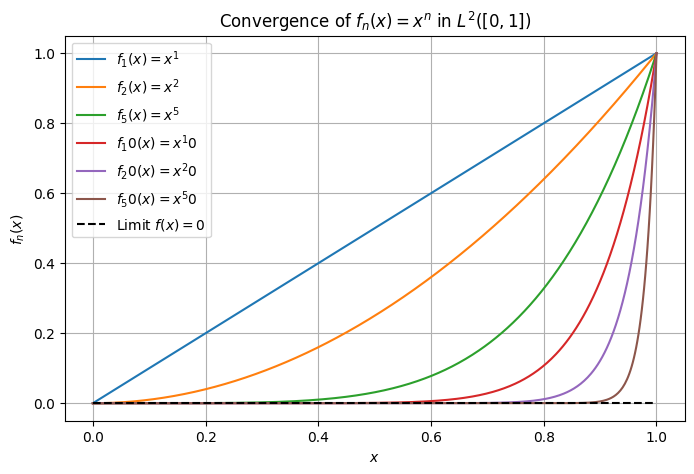

||f_1 - 0||_L2 ≈ 0.5774
||f_2 - 0||_L2 ≈ 0.4472
||f_5 - 0||_L2 ≈ 0.3015
||f_10 - 0||_L2 ≈ 0.2182
||f_20 - 0||_L2 ≈ 0.1562
||f_50 - 0||_L2 ≈ 0.0997


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Domain
x = np.linspace(0, 1, 500)

# Functions f_n(x) = x^n
n_values = [1, 2, 5, 10, 20, 50]

plt.figure(figsize=(8,5))

for n in n_values:
    f_n = x**n
    plt.plot(x, f_n, label=f'$f_{n}(x)=x^{n}$')

plt.plot(x, np.zeros_like(x), 'k--', label='Limit $f(x)=0$')
plt.xlabel('$x$')
plt.ylabel('$f_n(x)$')
plt.title('Convergence of $f_n(x)=x^n$ in $L^2([0,1])$')
plt.legend()
plt.grid(True)
plt.show()

# Optional: compute L2 norms of differences to the limit
for n in n_values:
    f_n = x**n
    L2_norm = np.sqrt(np.trapezoid((f_n - 0)**2, x))
    print(f"||f_{n} - 0||_L2 ≈ {L2_norm:.4f}")


Explanation:

- Each $f_n(x)=x^n$ is plotted on $[0,1]$.
- The dashed black line shows the $L^2$ limit $f(x)=0$.
- The printed L2_norm values quantify convergence: as $n$ increases, $|f_n-f|_{L^2}\to 0$.

💡 Note: visually, pointwise convergence is only true for $x\in[0,1)$; at $x=1$ the limit is 1, but in $L^2$ this single point does not affect the norm.

## sequential compactness vs total boundedness

This Python snippet uses matplotlib to illustrate sequences in a square:

<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-2710122883.py:26: SyntaxWarning: invalid escape sequence '\m'
  plt.title('Illustration: Totally Bounded vs Sequentially Compact in $\mathbb{R}^2$')


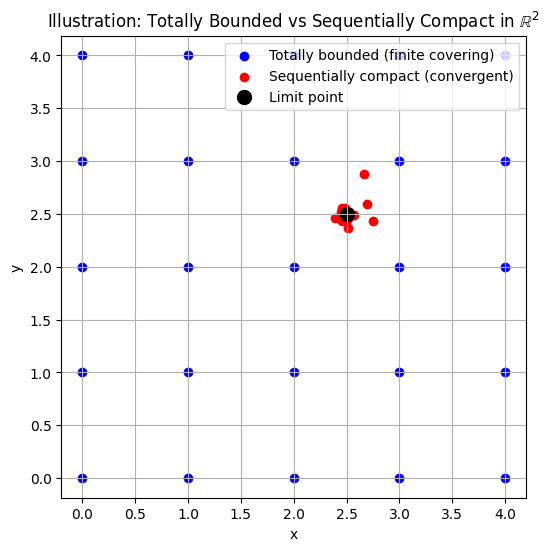

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Totally bounded set: grid points in [0,4]x[0,4]
x_grid, y_grid = np.meshgrid(np.arange(5), np.arange(5))
x_grid = x_grid.flatten()
y_grid = y_grid.flatten()

# Sequentially compact: random points converging to a limit
np.random.seed(42)
n_points = 50
limit = np.array([2.5, 2.5])
seq_points = limit + 0.5*np.random.randn(n_points,2)/np.arange(1,n_points+1)[:,None]

plt.figure(figsize=(6,6))

# Plot totally bounded points
plt.scatter(x_grid, y_grid, color='blue', label='Totally bounded (finite covering)')

# Plot sequentially compact points
plt.scatter(seq_points[:,0], seq_points[:,1], color='red', label='Sequentially compact (convergent)')

# Draw limit point
plt.scatter(*limit, color='black', s=100, label='Limit point')

plt.title('Illustration: Totally Bounded vs Sequentially Compact in $\mathbb{R}^2$')
plt.xlabel('x')
plt.ylabel('y')
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.show()


Conceptual takeaway for students:

- Totally bounded: every set can be covered with finitely many small balls — think of “grid points covered by circles.”
- Sequentially compact: every sequence has a convergent subsequence inside the set — think of points clustering to a limit inside the set.
- In $\mathbb{R}^n$, sequential compactness ⇔ compactness ⇔ closed + totally bounded.

## Same convergence under both metrics

Here’s a simple numerical illustration showing that $d_2$ (Euclidean) and $d_\infty$ (supremum) give equivalent notions of convergence on $\mathbb{R}^2$.

We construct a sequence $x_k\to0$ and measure both distances.

In [ ]:
import numpy as np

# Define the metrics
def d2(x, y):
    return np.linalg.norm(x - y)

def d_inf(x, y):
    return np.max(np.abs(x - y))

# Target point
y = np.array([0.0, 0.0])

# Sequence x_k = (1/k, (-1)^k / k)
ks = np.arange(1, 21)
points = np.array([[1/k, (-1)**k / k] for k in ks])

print(" k    d2(x_k,0)      d_inf(x_k,0)")
print("-----------------------------------")
for k, x in zip(ks, points):
    print(f"{k:2d}   {d2(x,y):.6f}     {d_inf(x,y):.6f}")


 k    d2(x_k,0)      d_inf(x_k,0)
-----------------------------------
 1   1.414214     1.000000
 2   0.707107     0.500000
 3   0.471405     0.333333
 4   0.353553     0.250000
 5   0.282843     0.200000
 6   0.235702     0.166667
 7   0.202031     0.142857
 8   0.176777     0.125000
 9   0.157135     0.111111
10   0.141421     0.100000
11   0.128565     0.090909
12   0.117851     0.083333
13   0.108786     0.076923
14   0.101015     0.071429
15   0.094281     0.066667
16   0.088388     0.062500
17   0.083189     0.058824
18   0.078567     0.055556
19   0.074432     0.052632
20   0.070711     0.050000


## Intermediate Value Theorem (IVT)



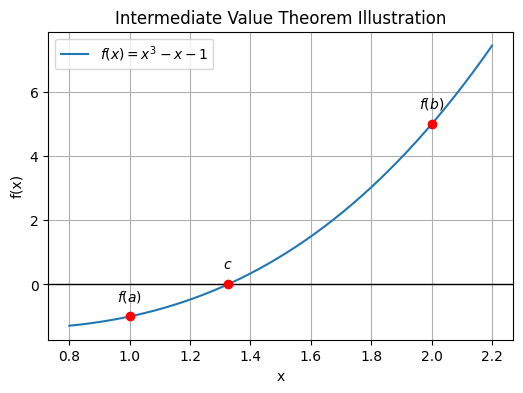

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define a continuous function
def f(x):
    return x**3 - x - 1

# Interval [a,b] where f(a)*f(b) < 0
a, b = 1, 2

# Fine grid for plotting
x = np.linspace(a-0.2, b+0.2, 500)
y = f(x)

# Compute the value at midpoint (for illustration)
c = 1.3247  # approximate root
y_c = f(c)

plt.figure(figsize=(6,4))
plt.plot(x, y, label=r'$f(x)=x^3-x-1$')
plt.axhline(0, color='black', linewidth=1)
plt.scatter([a,b,c], [f(a), f(b), y_c], color='red', zorder=5)
plt.text(a, f(a)+0.5, r'$f(a)$', ha='center')
plt.text(b, f(b)+0.5, r'$f(b)$', ha='center')
plt.text(c, y_c+0.5, r'$c$', ha='center')
plt.title('Intermediate Value Theorem Illustration')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.legend()
plt.show()


What this illustrates

1. $f(x)=x^3-x-1$ is continuous on $[1,2]$.
2. $f(1)=-1$, $f(2)=5$, so $f(1)\times f(2)<0$.
3. By IVT, there exists $c\in (1,2)$ such that $f(c)=0$.
4. Numerically, $c\approx 1.3247$ — the red point on the curve.

The plot shows that the curve crosses the x-axis, visualizing the theorem: a continuous function cannot ``jump over'' intermediate values.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def fixed_point_iteration(x0, n_iter=20):
    x = x0
    history = [x]
    for i in range(n_iter):
        x = np.cos(x)
        history.append(x)
    return history

x0 = 0.5
iterates = fixed_point_iteration(x0)
print("Iterates:")
for i, val in enumerate(iterates):
    print(f"x_{i} = {val:.10f}")


Iterates:
x_0 = 0.5000000000
x_1 = 0.8775825619
x_2 = 0.6390124942
x_3 = 0.8026851007
x_4 = 0.6947780268
x_5 = 0.7681958313
x_6 = 0.7191654459
x_7 = 0.7523557594
x_8 = 0.7300810631
x_9 = 0.7451203414
x_10 = 0.7350063090
x_11 = 0.7418265226
x_12 = 0.7372357254
x_13 = 0.7403296519
x_14 = 0.7382462383
x_15 = 0.7396499628
x_16 = 0.7387045394
x_17 = 0.7393414523
x_18 = 0.7389124493
x_19 = 0.7392014441
x_20 = 0.7390067798
